# Phase 3: Exploratory Data Analysis

Systematic EDA across six lenses: KPIs, time trends & seasonality, products, customers, geography and discounts. Each finding is framed as evidence for a business decision.

## Load cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
df = pd.read_csv('../data/cleaned/retail_sales_clean.csv', parse_dates=['Order_Date'])
print(df.shape)

(108045, 30)


## 1. Global KPIs

In [2]:
total_sales = df['Sales'].sum(); total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique(); total_customers = df['Customer_ID'].nunique()
print(f'Revenue: ${total_sales:,.0f}')
print(f'Profit: ${total_profit:,.0f}   Margin: {total_profit/total_sales:.1%}')
print(f'Orders: {total_orders:,}   Customers: {total_customers:,}')
print(f'Average Order Value: ${total_sales/total_orders:,.2f}')

Revenue: $68,905,247
Profit: $16,396,834   Margin: 23.8%
Orders: 33,209   Customers: 1,648
Average Order Value: $2,074.90


## 2. Time analysis
### Monthly revenue trend (2021-2024)

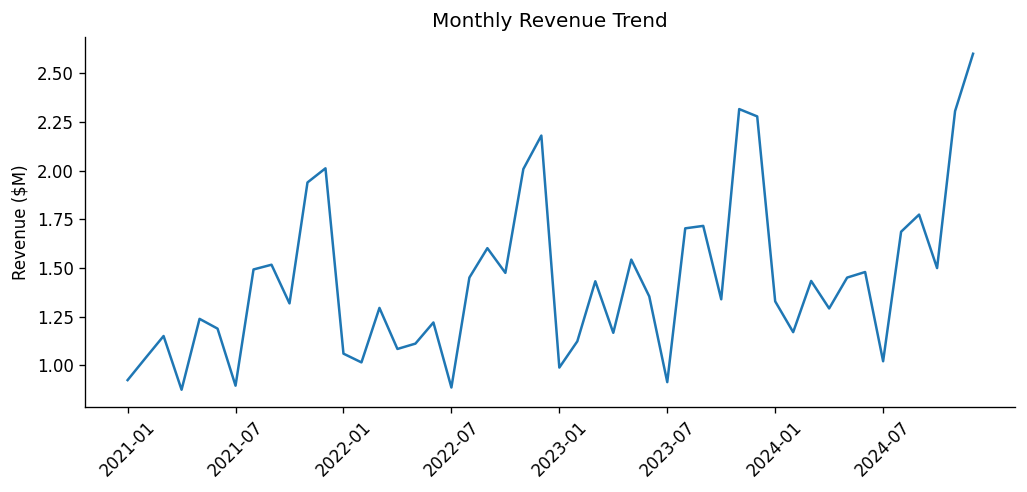

In [3]:
monthly = df.groupby(df['Order_Date'].dt.to_period('M')).agg(
    sales=('Sales', 'sum'), profit=('Profit', 'sum'), orders=('Order_ID', 'nunique'))
monthly.index = monthly.index.astype(str)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly['sales'] / 1e6)
ax.set_xticks(monthly.index[::6]); ax.set_xticklabels(monthly.index[::6], rotation=45)
ax.set_ylabel('Revenue ($M)'); ax.set_title('Monthly Revenue Trend'); plt.show()

### Yearly growth & CAGR

In [4]:
yearly = df.groupby('Order_Year').agg(sales=('Sales', 'sum')).reset_index()
yearly['growth'] = yearly['sales'].pct_change()
print(yearly.round(0).to_string(index=False))
cagr = (yearly['sales'].iloc[-1] / yearly['sales'].iloc[0]) ** (1/3) - 1
print(f'\nTotal growth 2021->2024: {yearly["sales"].iloc[-1]/yearly["sales"].iloc[0]-1:.1%} (CAGR {cagr:.1%})')

 Order_Year      sales  growth
       2021 15592053.0     NaN
       2022 16390860.0     0.0
       2023 17878039.0     0.0
       2024 19044295.0     0.0

Total growth 2021->2024: 22.1% (CAGR 6.9%)


### Seasonality — peak months

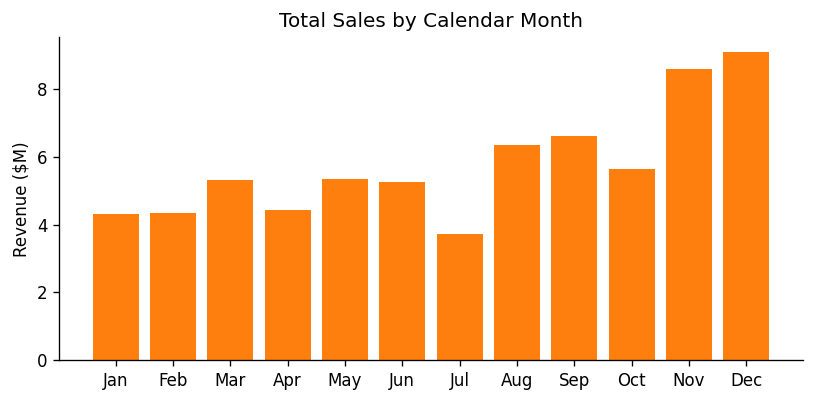

Peak month: December


In [5]:
seas = df.assign(cm=df['Order_Date'].dt.month).groupby('cm')['Sales'].sum()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(seas.index, seas.values / 1e6, color='#ff7f0e')
ax.set_xticks(seas.index)
ax.set_xticklabels([pd.Timestamp(2020, m, 1).strftime('%b') for m in seas.index])
ax.set_ylabel('Revenue ($M)'); ax.set_title('Total Sales by Calendar Month'); plt.show()
print('Peak month:', pd.Timestamp(2020, int(seas.idxmax()), 1).strftime('%B'))

## 3. Product analysis

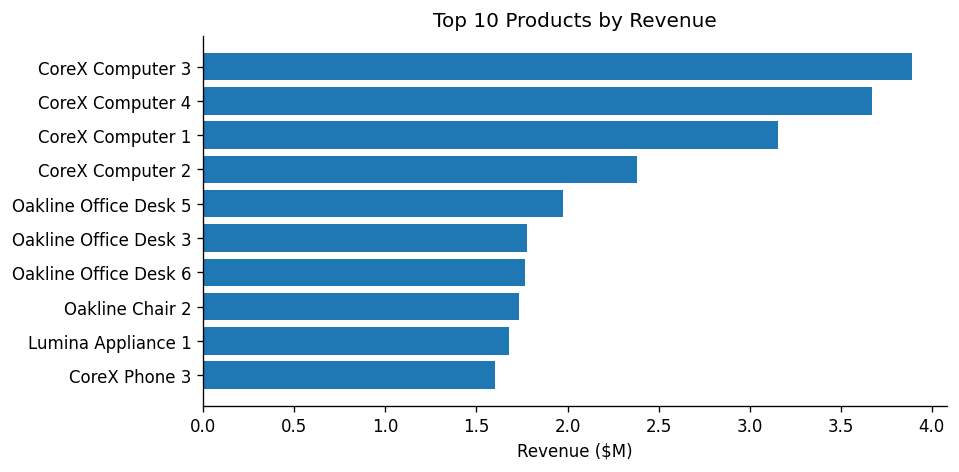

In [6]:
prod = df.groupby(['Product_ID', 'Product_Name', 'Category']).agg(
    sales=('Sales', 'sum'), profit=('Profit', 'sum'), orders=('Order_ID', 'nunique')).reset_index()
prod['margin'] = prod['profit'] / prod['sales']
top10 = prod.nlargest(10, 'sales')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top10['Product_Name'][::-1], top10['sales'][::-1] / 1e6)
ax.set_xlabel('Revenue ($M)'); ax.set_title('Top 10 Products by Revenue'); plt.show()

In [7]:
cat = df.groupby('Category').agg(sales=('Sales', 'sum'), profit=('Profit', 'sum')).sort_values('sales', ascending=False)
cat['margin'] = cat['profit'] / cat['sales']
cat['share'] = cat['sales'] / cat['sales'].sum()
print(cat.round(0).to_string())
print('\nInsight: Technology leads revenue but has the thinnest margin '
      '(high-volume, low-profit); Home & Lifestyle is the most profitable per dollar.')

                       sales     profit  margin  share
Category                                              
Technology        26152933.0  3242648.0     0.0    0.0
Furniture         24374048.0  7203359.0     0.0    0.0
Home & Lifestyle  11603427.0  4114806.0     0.0    0.0
Office Supplies    6774838.0  1836021.0     0.0    0.0

Insight: Technology leads revenue but has the thinnest margin (high-volume, low-profit); Home & Lifestyle is the most profitable per dollar.


## 4. Customer analysis
### Customer value distribution

In [8]:
cust = df.groupby('Customer_ID').agg(sales=('Sales', 'sum'), orders=('Order_ID', 'nunique'),
    segment=('Customer_Segment', 'first')).reset_index()
q75, q50 = cust['sales'].quantile(0.75), cust['sales'].quantile(0.50)
cust['tier'] = np.where(cust['sales'] >= q75, 'High-value',
                np.where(cust['sales'] >= q50, 'Mid-value', 'Low-value'))
tier = cust.groupby('tier').agg(customers=('Customer_ID', 'nunique'), revenue=('sales', 'sum'))
tier['share'] = tier['revenue'] / tier['revenue'].sum()
print(tier.round(0).to_string())
print(f'\nPareto: {tier.loc["High-value", "customers"]} customers (top 25%) '
      f'= {tier.loc["High-value", "share"]:.0%} of revenue')

            customers     revenue  share
tier                                    
High-value        412  50877946.0    1.0
Low-value         824   5485527.0    0.0
Mid-value         412  12541774.0    0.0

Pareto: 412 customers (top 25%) = 74% of revenue


### New vs returning customers

In [9]:
cust['first_year'] = df.sort_values('Order_Date').groupby('Customer_ID')['Order_Date'].first().dt.year
one_time = int((cust['orders'] == 1).sum())
print(f'One-time buyers: {one_time} ({one_time/len(cust):.0%})')
print(cust['first_year'].value_counts().sort_index())

One-time buyers: 146 (9%)
first_year
2021.0    1197
2022.0     174
2023.0      73
2024.0      60
Name: count, dtype: int64


## 5. Geography

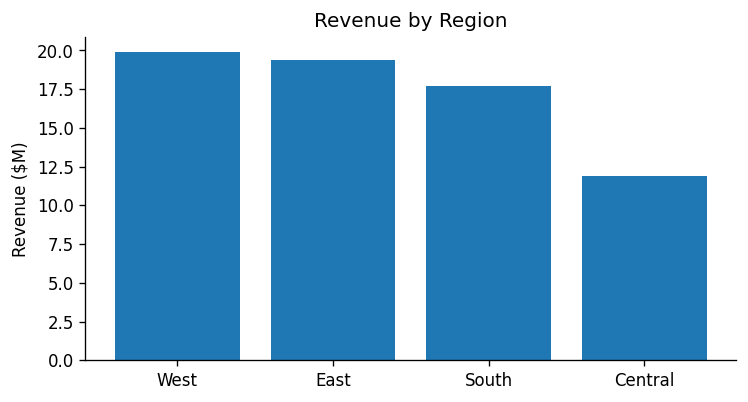

              sales     profit  margin  share
Region                                       
West     19877497.0  4675125.0     0.0    0.0
East     19399352.0  4626738.0     0.0    0.0
South    17728818.0  4243438.0     0.0    0.0
Central  11899580.0  2851533.0     0.0    0.0


In [10]:
reg = df.groupby('Region').agg(sales=('Sales', 'sum'), profit=('Profit', 'sum')).sort_values('sales', ascending=False)
reg['margin'] = reg['profit'] / reg['sales']
reg['share'] = reg['sales'] / reg['sales'].sum()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(reg.index, reg['sales'] / 1e6)
ax.set_ylabel('Revenue ($M)'); ax.set_title('Revenue by Region'); plt.show()
print(reg.round(0).to_string())

## 6. Discount analysis
### Do discounts actually help? Margin by discount band

In [11]:
band = df.groupby('Discount_Band', observed=True).agg(
    lines=('Sales', 'size'), revenue=('Sales', 'sum'), profit=('Profit', 'sum')).reset_index()
band['margin'] = band['profit'] / band['revenue']
print(band.round(4).to_string(index=False))
print('\nKey finding: 30%+ discounts turn lines unprofitable '
      '(margin < 0) without a meaningful volume lift.')

Discount_Band  lines     revenue     profit  margin
        0-10%  24875 16726067.46 4795596.23  0.2867
       10-20%  27181 16709377.41 3422835.20  0.2048
       20-30%  14469  7745234.85  767749.13  0.0991
         30%+   8205  3706905.90 -304800.52 -0.0822
  No Discount  33315 24017661.06 7715453.91  0.3212

Key finding: 30%+ discounts turn lines unprofitable (margin < 0) without a meaningful volume lift.
